In [10]:
import random
import re
import unicodedata
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import sys
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from collections import Counter

def remove_vietnamese_accents(text):
    accent_map = {
        'à': 'a', 'á': 'a', 'ả': 'a', 'ã': 'a', 'ạ': 'a',
        'ă': 'a', 'ằ': 'a', 'ắ': 'a', 'ẳ': 'a', 'ẵ': 'a', 'ặ': 'a',
        'â': 'a', 'ầ': 'a', 'ấ': 'a', 'ẩ': 'a', 'ẫ': 'a', 'ậ': 'a',
        'đ': 'd',
        'è': 'e', 'é': 'e', 'ẻ': 'e', 'ẽ': 'e', 'ẹ': 'e',
        'ê': 'e', 'ề': 'e', 'ế': 'e', 'ể': 'e', 'ễ': 'e', 'ệ': 'e',
        'ì': 'i', 'í': 'i', 'ỉ': 'i', 'ĩ': 'i', 'ị': 'i',
        'ò': 'o', 'ó': 'o', 'ỏ': 'o', 'õ': 'o', 'ọ': 'o',
        'ô': 'o', 'ồ': 'o', 'ố': 'o', 'ổ': 'o', 'ỗ': 'o', 'ộ': 'o',
        'ơ': 'o', 'ờ': 'o', 'ớ': 'o', 'ở': 'o', 'ỡ': 'o', 'ợ': 'o',
        'ù': 'u', 'ú': 'u', 'ủ': 'u', 'ũ': 'u', 'ụ': 'u',
        'ư': 'u', 'ừ': 'u', 'ứ': 'u', 'ử': 'u', 'ữ': 'u', 'ự': 'u',
        'ỳ': 'y', 'ý': 'y', 'ỷ': 'y', 'ỹ': 'y', 'ỵ': 'y',
        'À': 'A', 'Á': 'A', 'Ả': 'A', 'Ã': 'A', 'Ạ': 'A',
        'Ă': 'A', 'Ằ': 'A', 'Ắ': 'A', 'Ẳ': 'A', 'Ẵ': 'A', 'Ặ': 'A',
        'Â': 'A', 'Ầ': 'A', 'Ấ': 'A', 'Ẩ': 'A', 'Ẫ': 'A', 'Ậ': 'A',
        'Đ': 'D',
        'È': 'E', 'É': 'E', 'Ẻ': 'E', 'Ẽ': 'E', 'Ẹ': 'E',
        'Ê': 'E', 'Ề': 'E', 'Ế': 'E', 'Ể': 'E', 'Ễ': 'E', 'Ệ': 'E',
        'Ì': 'I', 'Í': 'I', 'Ỉ': 'I', 'Ĩ': 'I', 'Ị': 'I',
        'Ò': 'O', 'Ó': 'O', 'Ỏ': 'O', 'Õ': 'O', 'Ọ': 'O',
        'Ô': 'O', 'Ồ': 'O', 'Ố': 'O', 'Ổ': 'O', 'Ỗ': 'O', 'Ộ': 'O',
        'Ơ': 'O', 'Ờ': 'O', 'Ớ': 'O', 'Ở': 'O', 'Ỡ': 'O', 'Ợ': 'O',
        'Ù': 'U', 'Ú': 'U', 'Ủ': 'U', 'Ũ': 'U', 'Ụ': 'U',
        'Ư': 'U', 'Ừ': 'U', 'Ứ': 'U', 'Ử': 'U', 'Ữ': 'U', 'Ự': 'U',
        'Ỳ': 'Y', 'Ý': 'Y', 'Ỷ': 'Y', 'Ỹ': 'Y', 'Ỵ': 'Y'
    }

    result = ""
    for index, char in enumerate(text):
        result += accent_map.get(char, char)

    return result

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super(MultiHeadAttention, self).__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.depth = d_model // n_heads

        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear   = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)
        self.out_linear   = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.n_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        query = self.split_heads(self.query_linear(query), batch_size)
        key   = self.split_heads(self.key_linear(key), batch_size)
        value = self.split_heads(self.value_linear(value), batch_size)

        attention_scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            attention_scores += mask
        attention_weights = F.softmax(attention_scores, dim=-1)
        context = torch.matmul(attention_weights, value)
        context = context.permute(0, 2, 1, 3).contiguous().view(batch_size, -1, self.d_model)
        output = self.out_linear(context)
        return output

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.attention = MultiHeadAttention(d_model, n_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attn_output = self.attention(x, x, x, mask)
        x = self.layer_norm1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.layer_norm2(x + ffn_output)
        return x

class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = nn.Parameter(torch.randn(1, 1000, d_model))
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embedding(x) + self.positional_encoding[:, :x.size(1), :]
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = nn.Parameter(torch.randn(1, 1000, d_model))
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)
        self.output_linear = nn.Linear(d_model, vocab_size)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None, src_padding_mask=None, tgt_padding_mask=None):
        x = self.embedding(x) + self.positional_encoding[:, :x.size(1), :]
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, enc_output, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask)
        logits = self.output_linear(x)
        return logits


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.attention1 = MultiHeadAttention(d_model, n_heads)
        self.attention2 = MultiHeadAttention(d_model, n_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.layer_norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None, src_padding_mask=None, tgt_padding_mask=None):
        if tgt_padding_mask is not None:
            expanded_tgt_padding_mask = tgt_padding_mask.unsqueeze(1).unsqueeze(2)
            padding_mask = expanded_tgt_padding_mask.float() * -1e9
            if tgt_mask is not None:
                expanded_tgt_mask = tgt_mask.unsqueeze(0)
                expanded_tgt_mask = expanded_tgt_mask.unsqueeze(1)
                combined_tgt_mask = expanded_tgt_mask + padding_mask
            else:
                combined_tgt_mask = padding_mask
        else:
            combined_tgt_mask = tgt_mask.unsqueeze(0).unsqueeze(1) if tgt_mask is not None else None

        attn1_output = self.attention1(x, x, x, mask=combined_tgt_mask)
        x = self.layer_norm1(x + self.dropout(attn1_output))

        if src_padding_mask is not None:
            expanded_src_padding_mask = src_padding_mask.unsqueeze(1).unsqueeze(2)
            cross_mask = expanded_src_padding_mask.float() * -1e9
        else:
            cross_mask = None

        attn2_output = self.attention2(x, enc_output, enc_output, mask=cross_mask)
        x = self.layer_norm2(x + self.dropout(attn2_output))

        ffn_output = self.ffn(x)
        x = self.layer_norm3(x + self.dropout(ffn_output))
        return x

class Transformer(torch.nn.Module):
    def __init__(self, en_vocab_size, vi_vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1):
        super(Transformer, self).__init__()
        self.encoder = Encoder(en_vocab_size, d_model, n_heads, n_layers, d_ff, dropout)
        self.decoder = Decoder(vi_vocab_size, d_model, n_heads, n_layers, d_ff, dropout)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, src_padding_mask=None, tgt_padding_mask=None):
        enc_output = self.encoder(src, src_mask)
        logits = self.decoder(tgt, enc_output, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask)
        return logits

def generate_square_subsequent_mask(sz, DEVICE):
    mask = (torch.triu(torch.ones((sz, sz), device=DEVICE)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def create_mask(src, tgt, DEVICE, PAD_IDX):
    src_seq_len = src.shape[1]
    tgt_seq_len = tgt.shape[1]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len, DEVICE)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX)
    tgt_padding_mask = (tgt == PAD_IDX)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

In [12]:
def evaluate_bleu_score(model, valid_loader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX, out_vocab_transform):
    model.eval()
    bleu_scores = []

    with torch.no_grad():
        for batch in tqdm(valid_loader, desc="Calculating BLEU Scores"):
            src_batch, tgt_batch = batch
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            batch_size = src_batch.size(0)

            for i in range(batch_size):
                src = src_batch[i:i+1]

                tgt_reference = tgt_batch[i].cpu().numpy().tolist()
                clean_reference = [token_id for token_id in tgt_reference
                                  if token_id != pad_out_token_id and token_id != BOS_IDX and token_id != EOS_IDX]
                reference_tokens = out_vocab_transform.lookup_tokens(clean_reference)

                src_seq_len = src.size(1)
                src_mask = torch.zeros(src_seq_len, src_seq_len, device=device).type(torch.bool)

                generated = greedy_decode(model, src, src_mask, max_len=src_seq_len + 10, start_symbol=BOS_IDX, DEVICE=device)
                generated_ids = generated.squeeze(0).cpu().numpy().tolist()
                clean_generated = [token_id for token_id in generated_ids
                                  if token_id != pad_out_token_id and token_id != BOS_IDX and token_id != EOS_IDX]
                generated_tokens = out_vocab_transform.lookup_tokens(clean_generated)

                if len(generated_tokens) > len(reference_tokens):
                    generated_tokens = generated_tokens[:len(reference_tokens)]

                weights = [0.25, 0.25, 0.25, 0.25]
                precisions = []

                for n in range(1, 5):
                    if len(generated_tokens) < n:
                        precisions.append(0.0)
                        continue

                    gen_ngrams = Counter(zip(*[generated_tokens[i:] for i in range(n)]))

                    ref_ngrams = Counter(zip(*[reference_tokens[i:] for i in range(n)]))

                    clipped_count = sum(min(gen_ngrams[ng], ref_ngrams[ng]) for ng in gen_ngrams)

                    if sum(gen_ngrams.values()) == 0:
                        precisions.append(0.0)
                    else:
                        precisions.append(clipped_count / sum(gen_ngrams.values()))

                bp = 1.0
                if len(generated_tokens) < len(reference_tokens):
                    bp = math.exp(1 - len(reference_tokens) / len(generated_tokens)) if len(generated_tokens) > 0 else 0

                if 0.0 in precisions:
                    score = 0.0
                else:
                    score = bp * math.exp(sum(w * math.log(p) for w, p in zip(weights, precisions)))

                bleu_scores.append(score)

    avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0
    return avg_bleu


def evaluate_and_display_examples(model, test_loader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX, in_vocab_transform, out_vocab_transform, num_examples=5):
    model.eval()
    examples = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Displaying Examples"):
            src_batch, tgt_batch = batch
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            batch_size = src_batch.size(0)

            for i in range(min(batch_size, num_examples - len(examples))):
                src = src_batch[i:i+1]

                tgt_reference = tgt_batch[i].cpu().numpy().tolist()
                clean_reference = [token_id for token_id in tgt_reference
                                   if token_id != pad_out_token_id and token_id != BOS_IDX and token_id != EOS_IDX]

                src_tokens = [in_vocab_transform.lookup_tokens([id])[0] for id in src_batch[i].cpu().numpy().tolist()
                              if id != pad_in_token_id]

                src_text = " ".join(src_tokens)

                ref_tokens = out_vocab_transform.lookup_tokens(clean_reference)
                ref_text = " ".join(ref_tokens)

                src_seq_len = src.size(1)
                src_mask = torch.zeros(src_seq_len, src_seq_len, device=device).type(torch.bool)

                generated = greedy_decode(model, src, src_mask, max_len=src_seq_len + 10, start_symbol=BOS_IDX, DEVICE=device)
                generated_ids = generated.squeeze(0).cpu().numpy().tolist()
                clean_generated = [token_id for token_id in generated_ids
                                   if token_id != pad_out_token_id and token_id != BOS_IDX and token_id != EOS_IDX]

                if len(clean_generated) > len(clean_reference):
                    clean_generated = clean_generated[:len(clean_reference)]

                gen_tokens = out_vocab_transform.lookup_tokens(clean_generated)
                gen_text = " ".join(gen_tokens)

                is_match = clean_generated == clean_reference

                examples.append({
                    "source": src_text,
                    "reference": ref_text,
                    "generated": gen_text,
                    "exact_match": is_match
                })

                if len(examples) >= num_examples:
                    break

            if len(examples) >= num_examples:
                break

    print("\n===== Translation Examples =====")
    for i, example in enumerate(examples):
        print(f"\nExample {i+1}:")
        print(f"Source: {example['source']}")
        print(f"Reference: {example['reference']}")
        print(f"Generated: {example['generated']}")
        print(f"Exact match: {'✓' if example['exact_match'] else '✗'}")

    return examples


def evaluate_sentence_accuracy(model, valid_loader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX):
    model.eval()
    exact_matches = 0
    total_sentences = 0

    with torch.no_grad():
        for batch in tqdm(valid_loader, desc="Evaluating Sentence Accuracy"):
            src_batch, tgt_batch = batch
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            batch_size = src_batch.size(0)
            total_sentences += batch_size

            for i in range(batch_size):
                src = src_batch[i:i+1]

                tgt_reference = tgt_batch[i].cpu().numpy().tolist()
                clean_reference = [token_id for token_id in tgt_reference
                                  if token_id != pad_out_token_id and token_id != BOS_IDX and token_id != EOS_IDX]

                src_seq_len = src.size(1)
                src_mask = torch.zeros(src_seq_len, src_seq_len, device=device).type(torch.bool)

                generated = greedy_decode(model, src, src_mask, max_len=src_seq_len + 10, start_symbol=BOS_IDX, DEVICE=device)

                generated_ids = generated.squeeze(0).cpu().numpy().tolist()
                clean_generated = [token_id for token_id in generated_ids
                                  if token_id != pad_out_token_id and token_id != BOS_IDX and token_id != EOS_IDX]

                if len(clean_generated) > len(clean_reference):
                    clean_generated = clean_generated[:len(clean_reference)]

                if clean_generated == clean_reference:
                    exact_matches += 1

    sentence_accuracy = (exact_matches / total_sentences) * 100 if total_sentences > 0 else 0
    return sentence_accuracy, exact_matches, total_sentences


In [13]:
def train(model, train_loader, valid_loader, criterion, optimizer, device, pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX, in_vocab_transform, out_vocab_transform, num_epochs=10):
    train_losses = []
    train_accuracies = []
    train_bleu_scores = []
    train_sentence_accs = []
    valid_accuracies = []
    valid_losses = []
    valid_bleu_scores = []
    valid_sentence_accs = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_batches = len(train_loader)

        for batch_idx, batch in enumerate(train_loader):
            encoder_input, decoder_target = batch
            encoder_input = encoder_input.to(device)
            decoder_target = decoder_target.to(device).long()

            tgt_input = decoder_target[:, :-1]
            tgt_out = decoder_target[:, 1:]

            src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(encoder_input, tgt_input, device, pad_in_token_id)

            optimizer.zero_grad()

            outputs = model(encoder_input, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask)

            loss = criterion(outputs.reshape(-1, outputs.shape[-1]), tgt_out.reshape(-1))
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            sys.stdout.write(f"\rEpoch [{epoch + 1:2d}/{num_epochs}] Batch [{batch_idx + 1}/{total_batches}], Loss: {loss.item():.4f}")
            sys.stdout.flush()

        avg_train_loss = running_loss / total_batches
        train_losses.append(avg_train_loss)

        print(f"\nEvaluating metrics for epoch {epoch + 1}...")

        # Evaluate on training set
        print("Evaluating on training set...")
        model.eval()

        # Standard evaluation on training set
        train_accuracy, _ = evaluate(model, train_loader, criterion, device, pad_in_token_id)
        train_accuracies.append(train_accuracy)

        # Evaluate BLEU score on random 5000 samples from training set
        train_subset_loader = create_subset_loader(train_loader, 500)
        train_bleu = evaluate_bleu_score(model, train_subset_loader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX, out_vocab_transform)
        train_bleu_scores.append(train_bleu)

        # Evaluate sentence accuracy on random 5000 samples from training set
        train_subset_loader_2 = create_subset_loader(train_loader, 500)
        train_sent_acc, train_exact_matches, train_total = evaluate_sentence_accuracy(model, train_subset_loader_2, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX)
        train_sentence_accs.append(train_sent_acc)

        # Evaluate on validation set
        print("Evaluating on validation set...")
        # Standard evaluation
        valid_accuracy, valid_loss = evaluate(model, valid_loader, criterion, device, pad_in_token_id)
        valid_accuracies.append(valid_accuracy)
        valid_losses.append(valid_loss)

        # Evaluate BLEU score on random 5000 samples from validation set
        val_subset_loader = create_subset_loader(valid_loader, 500)
        val_bleu = evaluate_bleu_score(model, val_subset_loader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX, out_vocab_transform)
        valid_bleu_scores.append(val_bleu)

        # Evaluate sentence accuracy on random 5000 samples from validation set
        val_subset_loader_2 = create_subset_loader(valid_loader, 500)
        val_sent_acc, val_exact_matches, val_total = evaluate_sentence_accuracy(model, val_subset_loader_2, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX)
        valid_sentence_accs.append(val_sent_acc)

        # Print metrics summary
        print(f"\nEpoch [{epoch + 1:2d}/{num_epochs}] Summary:")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
        print(f"Train BLEU: {train_bleu:.4f}, Train Sentence Acc: {train_sent_acc:.2f}% ({train_exact_matches}/{train_total})")
        print(f"Val Loss: {valid_loss:.4f}, Val Acc: {valid_accuracy:.4f}")
        print(f"Val BLEU: {val_bleu:.4f}, Val Sentence Acc: {val_sent_acc:.2f}% ({val_exact_matches}/{val_total})")

        # Display 5 examples from validation set
        evaluate_and_display_examples(model, valid_loader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX, in_vocab_transform, out_vocab_transform, num_examples=5)

    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'train_bleu_scores': train_bleu_scores,
        'train_sentence_accs': train_sentence_accs,
        'valid_losses': valid_losses,
        'valid_accuracies': valid_accuracies,
        'valid_bleu_scores': valid_bleu_scores,
        'valid_sentence_accs': valid_sentence_accs
    }

def evaluate(model, valid_loader, criterion, device, pad_token_id):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    total_batches = len(valid_loader)

    with torch.no_grad():
        for batch_idx, batch in enumerate(valid_loader):
            encoder_input, decoder_target = batch
            encoder_input = encoder_input.to(device)
            decoder_target = decoder_target.to(device)

            tgt_input = decoder_target[:, :-1]
            tgt_out = decoder_target[:, 1:]

            src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(encoder_input, tgt_input, device, pad_token_id)

            outputs = model(encoder_input, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask)

            loss = criterion(outputs.reshape(-1, outputs.shape[-1]), tgt_out.reshape(-1))
            running_loss += loss.item()

            _, predicted = torch.max(outputs, dim=-1)
            all_preds.extend(predicted.reshape(-1).cpu().numpy())
            all_labels.extend(tgt_out.reshape(-1).cpu().numpy())

            sys.stdout.write(f"\rBatch [{batch_idx + 1}/{total_batches}], Loss: {loss.item():.4f}")
            sys.stdout.flush()

    accuracy = accuracy_score(all_labels, all_preds)
    avg_valid_loss = running_loss / total_batches
    return accuracy, avg_valid_loss

def create_subset_loader(dataloader, num_samples):
    dataset = dataloader.dataset
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    subset = torch.utils.data.Subset(dataset, indices)
    return torch.utils.data.DataLoader(subset, batch_size=dataloader.batch_size)

In [14]:
import string
import torch
from torch.utils.data import Dataset

class TranslationDatasetFull(Dataset):
    def __init__(self, in_file, out_file, in_vocab, out_vocab, is_augmentation=False, max_len=50):
        self.in_sentences = self._load_sentences(in_file)
        self.out_sentences = self._load_sentences(out_file)
        self.in_vocab = in_vocab
        self.out_vocab = out_vocab
        self.max_len = max_len
        self.is_augmentation = is_augmentation

    def _load_sentences(self, file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            sentences = f.readlines()
        return sentences

    def _encode_sentence(self, sentence, vocab, max_len):
        sentence = sentence.strip().lower()
        sentence = sentence.translate(str.maketrans("", "", string.punctuation))
        tokens = sentence.split()
        token_ids = [vocab.get(token, vocab['<unk>']) for token in tokens]
        token_ids = token_ids[:max_len] + [vocab['<pad>']] * (max_len - len(token_ids))
        return token_ids

    def _encode_decoder_sentence(self, sentence, vocab, max_len):
        sentence = sentence.strip().lower()
        sentence = sentence.translate(str.maketrans("", "", string.punctuation))
        tokens = sentence.split()
        full_tokens = [vocab['<seqstart>']] + [vocab.get(token, vocab['<unk>']) for token in tokens] + [vocab['<seqend>']]
        if len(full_tokens) < max_len:
            full_tokens += [vocab['<pad>']] * (max_len - len(full_tokens))
        else:
            full_tokens = full_tokens[:max_len]
        return full_tokens

    def __len__(self):
        return len(self.in_sentences)

    def __getitem__(self, idx):
        in_sentence = self.in_sentences[idx]
        out_sentence = self.out_sentences[idx]

        if self.is_augmentation:
            # out_sentence = vietnamese_text_augmentation(out_sentence, p=0.05)
            in_sentence = remove_vietnamese_accents(out_sentence)

        src = self._encode_sentence(in_sentence, self.in_vocab, self.max_len)
        tgt = self._encode_decoder_sentence(out_sentence, self.out_vocab, self.max_len)
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


In [15]:
import pickle
import os

def build_vocab(file_path=None, max_len=10000, vocab_path=None):
    if vocab_path is not None and os.path.exists(vocab_path):
        with open(vocab_path, 'rb') as f:
            vocab = pickle.load(f)
        print(f"Vocab loaded from {vocab_path}")
        return vocab
    elif file_path:
        print(f"Vocab not found at {vocab_path}, building vocab from scratch.")
        with open(file_path, 'r', encoding='utf-8') as f:
            sentences = f.readlines()

        all_words = []
        for index, sentence in enumerate(sentences):
            sentence = sentence.strip().lower()
            sentence = sentence.translate(str.maketrans("", "", string.punctuation))
            all_words.extend(sentence.split())

            sys.stdout.write(f"\rProcessing {file_path}, {index + 1:6d} | {len(sentences)}")
            sys.stdout.flush()

        word_counts = Counter(all_words)

        vocab = {word: idx for idx, (word, _) in enumerate(word_counts.most_common(max_len), 1)}
        vocab['<unk>'] = 0
        vocab['<pad>'] = len(vocab)
        vocab['<seqstart>'] = len(vocab)
        vocab['<seqend>'] = len(vocab)
        print()
        with open(vocab_path, 'wb') as f:
            pickle.dump(vocab, f)
        return vocab
    else:
        raise ValueError("No vocab file found and no file_path provided to build from.")


In [16]:
import os

def evaluate_model_on_test(model, test_dataloader, criterion, device, pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX, in_vocab_transform, out_vocab_transform):
    """Evaluate model on test set with all metrics"""
    print("\n===== Evaluating Model on Test Set =====")

    # Standard evaluation
    test_accuracy, test_loss = evaluate(model, test_dataloader, criterion, device, pad_in_token_id)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    # BLEU score evaluation
    bleu_test = evaluate_bleu_score(model, test_dataloader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX, out_vocab_transform)
    print(f"Test BLEU Score: {bleu_test:.4f}")

    # Sentence accuracy
    sent_acc, exact_matches, total = evaluate_sentence_accuracy(model, test_dataloader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX)
    print(f"Test Sentence Accuracy: {sent_acc:.2f}% ({exact_matches}/{total})")

    # Display examples
    examples = evaluate_and_display_examples(model, test_dataloader, device, pad_out_token_id, pad_in_token_id, BOS_IDX, EOS_IDX, in_vocab_transform, out_vocab_transform, num_examples=5)

    return {
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'test_bleu': bleu_test,
        'test_sentence_accuracy': sent_acc,
        'test_examples': examples
    }


def visualize_metrics(metrics, save_path=None):
    """Visualize all training and validation metrics"""
    plt.figure(figsize=(20, 15))

    # Plot 1: Train and Validation Loss
    plt.subplot(2, 2, 1)
    plt.plot(metrics['train_losses'], label='Training Loss')
    plt.plot(metrics['valid_losses'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Token Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(metrics['train_accuracies'], label='Train Token Accuracy', color='blue')
    plt.plot(metrics['valid_accuracies'], label='Val Token Accuracy', color='green')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Token Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot 3: BLEU Score
    plt.subplot(2, 2, 3)
    plt.plot(metrics['train_bleu_scores'], label='Train BLEU Score', color='darkblue')
    plt.plot(metrics['valid_bleu_scores'], label='Val BLEU Score', color='purple')
    plt.xlabel('Epochs')
    plt.ylabel('BLEU Score')
    plt.title('BLEU Score')
    plt.legend()
    plt.grid(True)

    # Plot 4: Sentence Accuracy
    plt.subplot(2, 2, 4)
    plt.plot(metrics['train_sentence_accs'], label='Train Sentence Accuracy', color='red')
    plt.plot(metrics['valid_sentence_accs'], label='Val Sentence Accuracy', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Sentence Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)

    plt.show()

    # Create a separate figure for comparing final metrics
    plt.figure(figsize=(12, 8))

    metrics_names = ['Token Accuracy', 'BLEU Score', 'Sentence Accuracy (%)']
    train_values = [metrics['train_accuracies'][-1] * 100,
                    metrics['train_bleu_scores'][-1] * 100,
                    metrics['train_sentence_accs'][-1]]
    val_values = [metrics['valid_accuracies'][-1] * 100,
                 metrics['valid_bleu_scores'][-1] * 100,
                 metrics['valid_sentence_accs'][-1]]

    x = np.arange(len(metrics_names))
    width = 0.35

    plt.bar(x - width/2, train_values, width, label='Train', color='blue', alpha=0.7)
    plt.bar(x + width/2, val_values, width, label='Validation', color='orange', alpha=0.7)

    plt.ylabel('Score (%)')
    plt.title('Final Training vs. Validation Metrics')
    plt.xticks(x, metrics_names)
    plt.legend()

    # Add values on top of bars
    for i, v in enumerate(train_values):
        plt.text(i - width/2, v + 1, f"{v:.2f}%", ha='center')

    for i, v in enumerate(val_values):
        plt.text(i + width/2, v + 1, f"{v:.2f}%", ha='center')

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    if save_path:
        base, ext = os.path.splitext(save_path)
        plt.savefig(f"{base}_comparison{ext}")

    plt.show()


def train_and_evaluate_model(model, train_dataloader, val_dataloader, test_dataloader, criterion, optimizer, device,
                             pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX, in_vocab_transform, out_vocab_transform,
                             num_epochs=10):

    # Train the model
    print("Starting training...")
    metrics = train(model, train_dataloader, val_dataloader, criterion, optimizer, device,
                   pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX, in_vocab_transform, out_vocab_transform,
                   num_epochs=num_epochs)

    # Visualize training metrics
    visualize_metrics(metrics, save_path="training_metrics.png")

    # Plot metric trends separately
    plot_metric_trends(metrics)

    return metrics


def plot_metric_trends(metrics):
    """Create more detailed trend visualizations for each metric"""

    # 1. Token Accuracy Comparison
    plt.figure(figsize=(12, 8))
    plt.plot(metrics['train_accuracies'], marker='o', linestyle='-', label='Train')
    plt.plot(metrics['valid_accuracies'], marker='s', linestyle='-', label='Validation')
    plt.title('Token-level Accuracy Over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.savefig("token_accuracy_trends.png")
    plt.show()

    # 2. BLEU Score Comparison
    plt.figure(figsize=(12, 8))
    plt.plot(metrics['train_bleu_scores'], marker='o', linestyle='-', label='Train')
    plt.plot(metrics['valid_bleu_scores'], marker='s', linestyle='-', label='Validation')
    plt.title('BLEU Score Over Training')
    plt.xlabel('Epochs')
    plt.ylabel('BLEU Score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.savefig("bleu_score_trends.png")
    plt.show()

    # 3. Sentence Accuracy Comparison
    plt.figure(figsize=(12, 8))
    plt.plot(metrics['train_sentence_accs'], marker='o', linestyle='-', label='Train')
    plt.plot(metrics['valid_sentence_accs'], marker='s', linestyle='-', label='Validation')
    plt.title('Sentence Accuracy Over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Sentence Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.savefig("sentence_accuracy_trends.png")
    plt.show()

    # 4. Loss Comparison
    plt.figure(figsize=(12, 8))
    plt.plot(metrics['train_losses'], marker='o', linestyle='-', label='Train')
    plt.plot(metrics['valid_losses'], marker='s', linestyle='-', label='Validation')
    plt.title('Loss Over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.savefig("loss_trends.png")
    plt.show()

In [17]:
import os

current_path = os.getcwd()
print("Thư mục hiện tại:", current_path)

items = os.listdir(current_path)
print("Danh sách file và thư mục:")
for item in items:
    print("-", item)


Thư mục hiện tại: d:\HK8\NPL
Danh sách file và thư mục:
- .git
- clean_data.ipynb
- crawlers_fixed.py
- dataset
- encode_data.ipynb
- raw_data
- trainning.ipynb
- utils.py
- vocab
- __pycache__


In [18]:
print(os.listdir("vocab"))


['in_vocab.pkl', 'out_vocab.pkl', 'vocabulary.json']


In [19]:
import pickle

NUM_EPOCHS = 10
DIM_MODEL = 512
LEARNING_RATE = 0.0001
BATCH = 512

in_vocab = build_vocab(file_path="", max_len=10000, vocab_path="vocab/in_vocab.pkl")
out_vocab = build_vocab(file_path="", max_len=10000, vocab_path="vocab/out_vocab.pkl")

N_HEADS = 8
N_LAYERS = 4
D_FF = 512
DROPOUT = 0.1

IN_VOCAB_SIZE = len(in_vocab)
OUT_VOCAB_SIZE = len(out_vocab)

BOS_IDX = out_vocab['<seqstart>']
EOS_IDX = out_vocab['<seqend>']

print(f"Input vocab size: {IN_VOCAB_SIZE}, Output vocab size: {OUT_VOCAB_SIZE}")

Vocab loaded from vocab/in_vocab.pkl
Vocab loaded from vocab/out_vocab.pkl
Input vocab size: 1122, Output vocab size: 2458


In [20]:
def generate_square_subsequent_mask(sz, DEVICE):
    mask = (torch.triu(torch.ones((sz, sz), device=DEVICE)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask


def greedy_decode(model, src, src_mask, max_len, start_symbol, DEVICE):
    src = src.to(DEVICE)
    src_mask = src_mask.to(DEVICE)

    memory = model.encoder(src, src_mask)

    ys = torch.ones(src.size(0), 1).fill_(start_symbol).type(torch.long).to(DEVICE)

    for i in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(1), DEVICE).to(DEVICE)

        out = model.decoder(ys, memory, src_mask, tgt_mask, None, None)

        out_last = out[:, -1, :]

        prob = out_last
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat([ys, torch.tensor([[next_word]], device=DEVICE)], dim=1)

        if next_word == EOS_IDX:
            break

    return ys

def simple_text_transform(sentence: str):
    sentence = sentence.strip().lower()
    sentence = sentence.translate(str.maketrans("", "", string.punctuation))
    tokens = sentence.split()
    token_ids = [in_vocab.get(token, in_vocab['<unk>']) for token in tokens]
    return torch.tensor(token_ids, dtype=torch.long).unsqueeze(0)

class SimpleVocab:
    def __init__(self, vocab):
        self.vocab = vocab
        self.inv_vocab = {id: token for token, id in vocab.items()}
    def lookup_tokens(self, ids):
        return [self.inv_vocab.get(i, "<unk>") for i in ids]

out_vocab_transform = SimpleVocab(out_vocab)
in_vocab_transform = SimpleVocab(in_vocab)

In [21]:
from torch.utils.data import DataLoader

train_output_file = "dataset/train/label.txt"
train_input_file = "dataset/train/source.txt"

train_dataset = TranslationDatasetFull(train_input_file, train_output_file, in_vocab, out_vocab, is_augmentation=True, max_len=50)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)

val_output_file = "dataset/val/label.txt"
val_input_file = "dataset/val/source.txt"

val_dataset = TranslationDatasetFull(val_input_file, val_output_file, in_vocab, out_vocab, max_len=50)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH, shuffle=True)

test_output_file = "dataset/test/label.txt"
test_input_file = "dataset/test/source.txt"

test_dataset = TranslationDatasetFull(test_input_file, test_output_file, in_vocab, out_vocab, max_len=50)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = Transformer(IN_VOCAB_SIZE, OUT_VOCAB_SIZE, DIM_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT)
model = model.to(device)

cpu


In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98))

In [24]:
pad_out_token_id = out_vocab.get('<pad>', 0)
pad_in_token_id = in_vocab.get('<pad>', 0)

print(pad_out_token_id, pad_in_token_id)

2455 1119


In [ ]:
metrics = train_and_evaluate_model(
    model, train_dataloader, val_dataloader, test_dataloader,
    criterion, optimizer, device,
    pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX,
    in_vocab_transform, out_vocab_transform,
    num_epochs=6
)

Starting training...
Epoch [ 1/6] Batch [16/125], Loss: 1.9440

Starting training...
Epoch [ 1/2] Batch [594/594], Loss: 0.0067
Evaluating metrics for epoch 1...
Evaluating on training set...
Batch [594/594], Loss: 0.0024

Evaluating Sentence Accuracy: 100%|██████████| 1/1 [00:45<00:00, 45.75s/it]


Evaluating on validation set...
Batch [149/149], Loss: 0.0127

Evaluating Sentence Accuracy: 100%|██████████| 1/1 [00:45<00:00, 45.93s/it]



Epoch [ 1/2] Summary:
Train Loss: 0.0063, Train Acc: 0.9992
Train BLEU: 0.8744, Train Sentence Acc: 94.00% (470/500)
Val Loss: 0.0118, Val Acc: 0.9967
Val BLEU: 0.8218, Val Sentence Acc: 85.20% (426/500)


...

Evaluating on validation set...
Batch [149/149], Loss: 0.0159

Evaluating Sentence Accuracy: 100%|██████████| 1/1 [01:00<00:00, 60.88s/it]



Epoch [ 2/2] Summary:
Train Loss: 0.0052, Train Acc: 0.9994
Train BLEU: 0.8873, Train Sentence Acc: 93.80% (469/500)
Val Loss: 0.0120, Val Acc: 0.9967
Val BLEU: 0.8378, Val Sentence Acc: 86.40% (432/500)


Displaying Examples:   0%|          | 0/149 [00:00<?, ?it/s]



===== Translation Examples =====

Example 1:
Source: anh se di rua bat ngay lap tuc
Reference: anh sẽ đi rửa bát ngay lập tức
Generated: anh sẽ đi rửa bát ngay lập tức
Exact match: ✓

Example 2:
Source: va bay gio toi nghi toi dang bi cam
Reference: và bây giờ tôi nghĩ tôi đang bị cảm
Generated: và bây giờ tôi nghĩ tôi đang bị cảm
Exact match: ✓

Example 3:
Source: ban biet toi dung
Reference: bạn biết tôi đúng
Generated: bạn biết tôi đúng
Exact match: ✓

Example 4:
Source: toi tung me dam ong
Reference: tôi từng mê đắm ông
Generated: tôi từng mê đắm ông
Exact match: ✓

Example 5:
Source: tom duong nhu dang an mung
Reference: tom dường như đang ăn mừng
Generated: tom dường như đang ăn mừng
Exact match: ✓


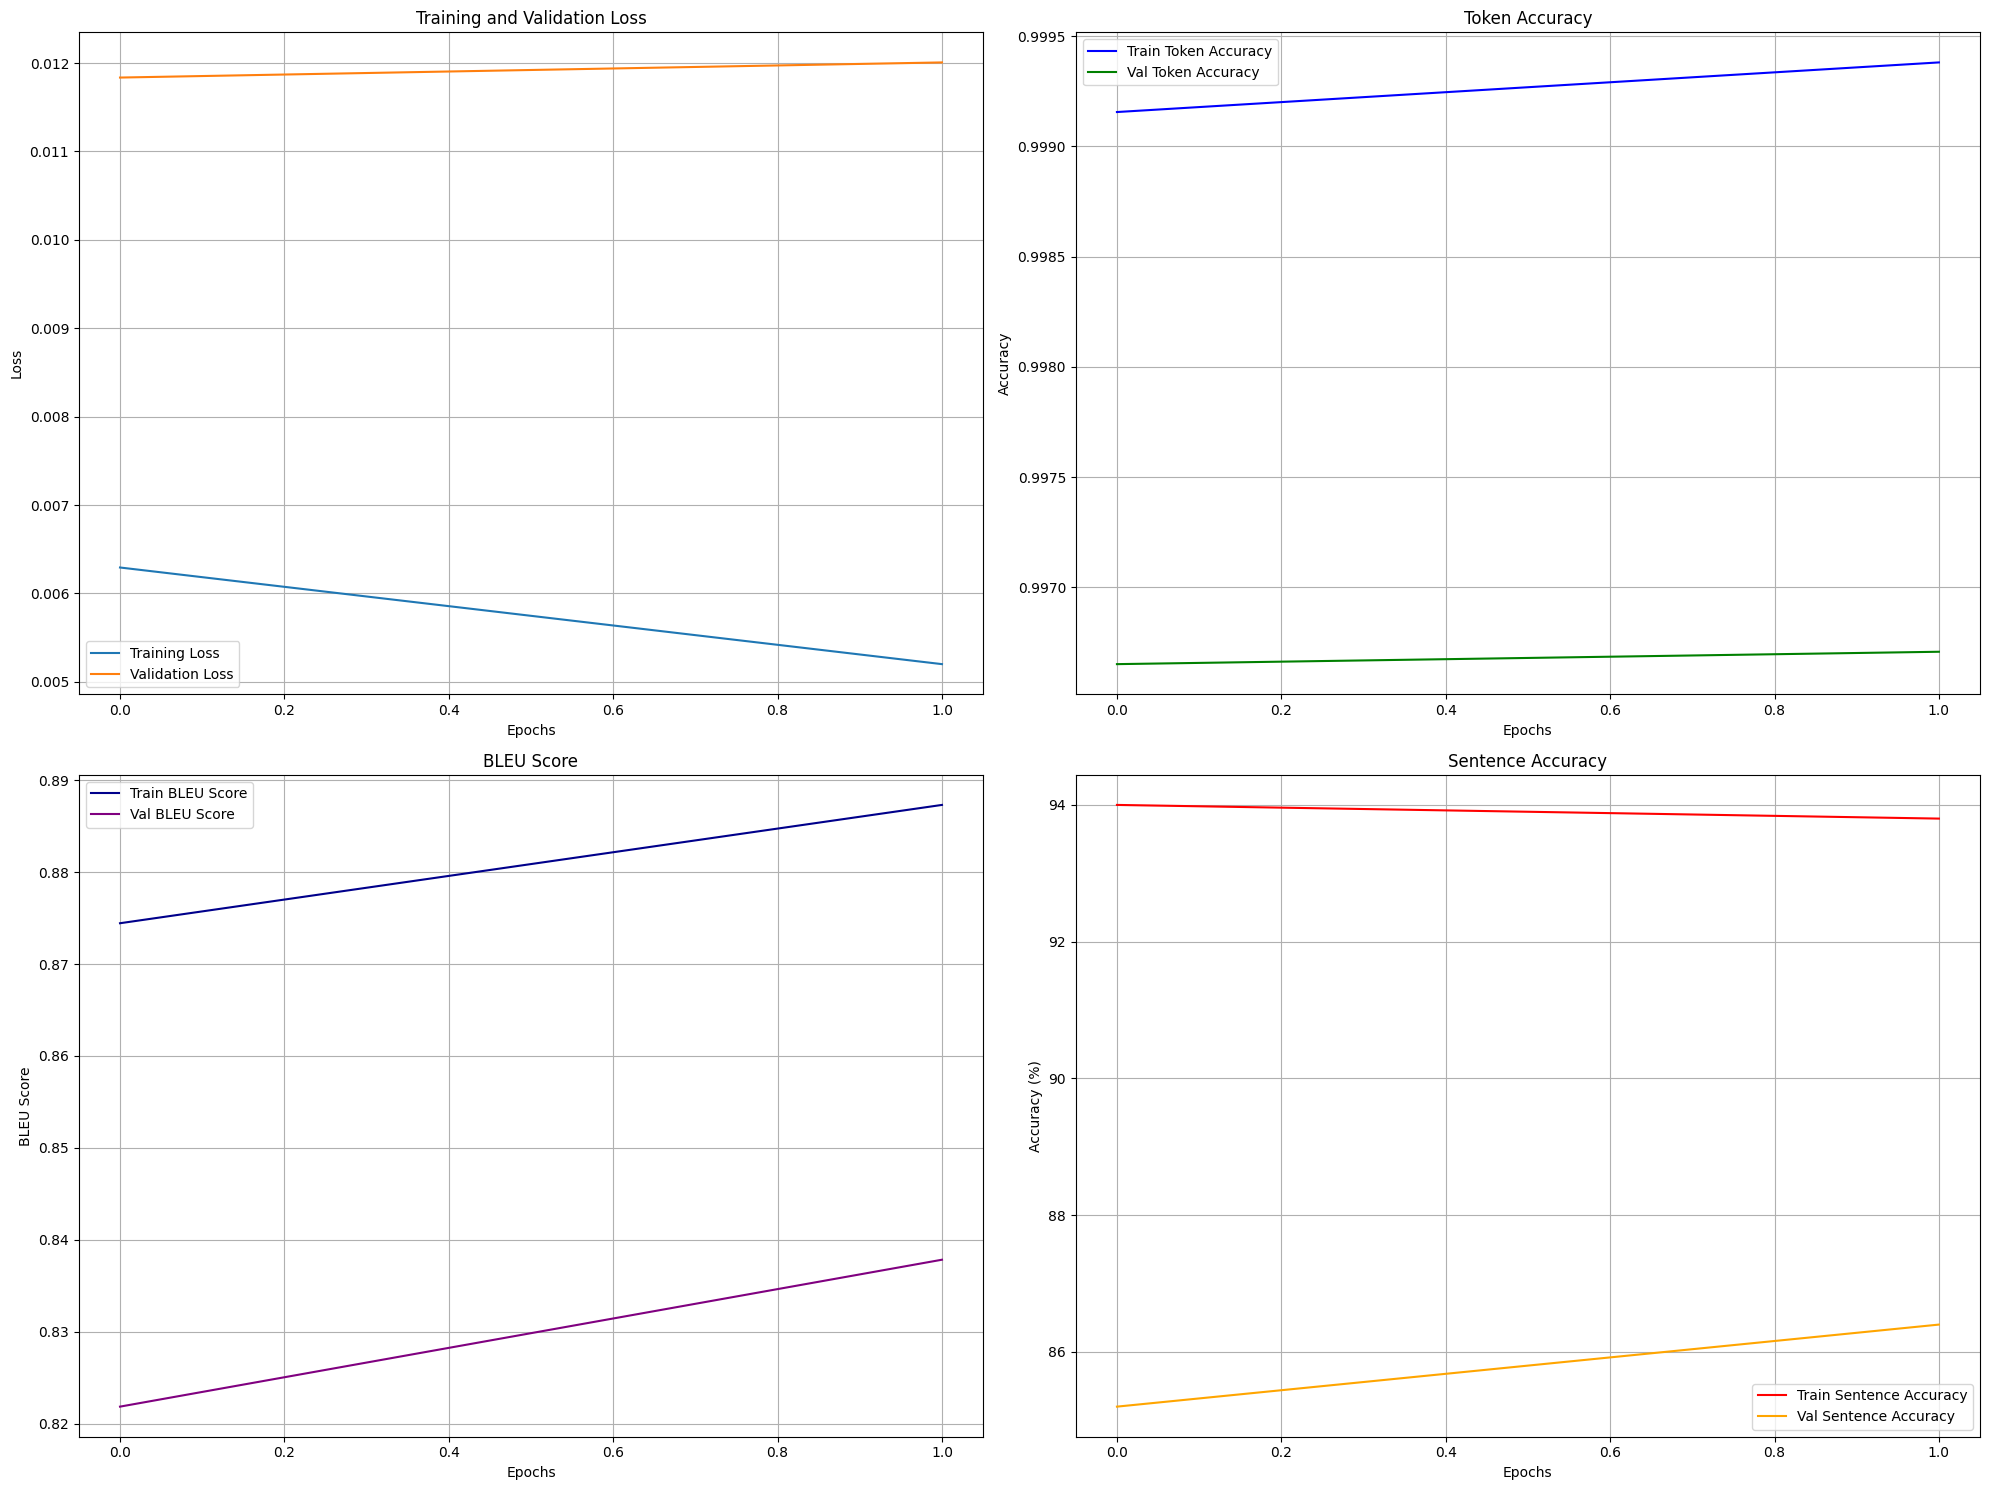

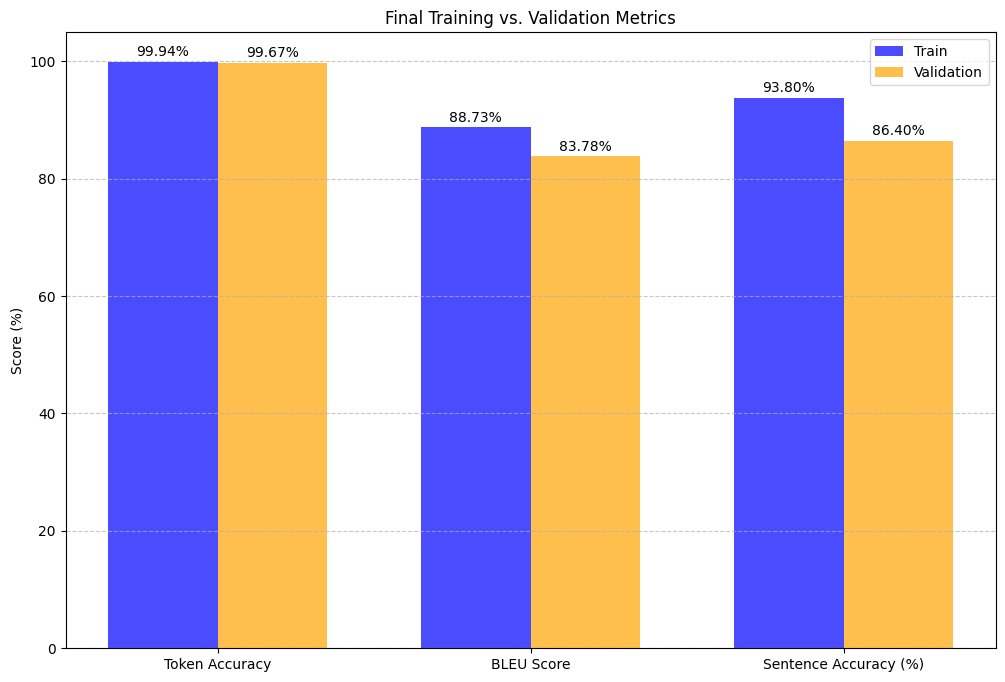

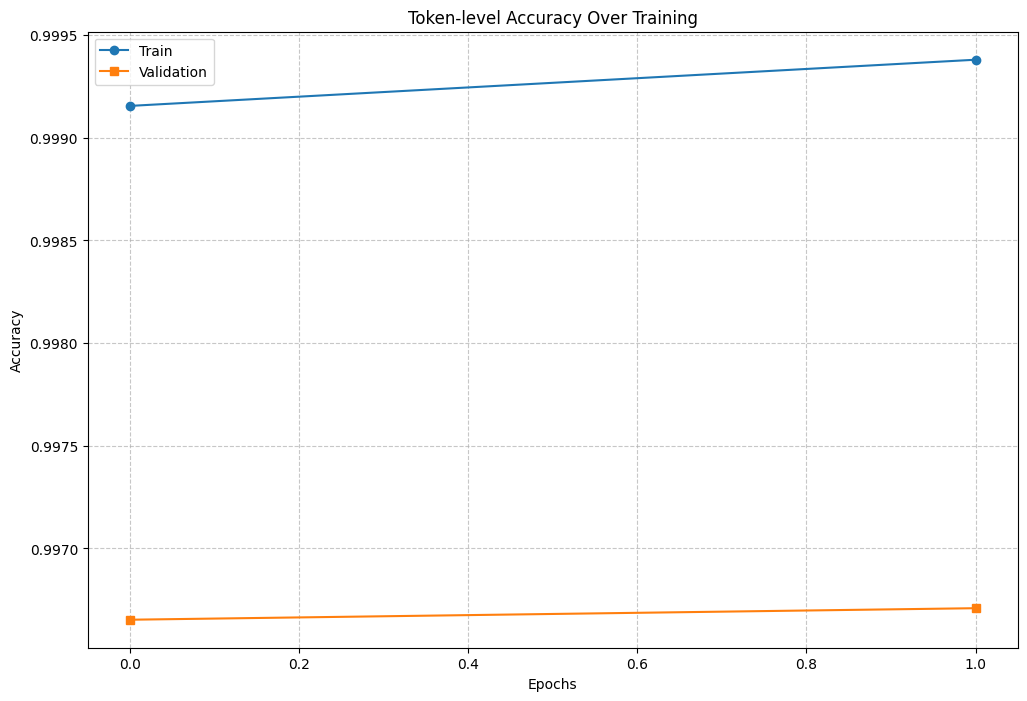

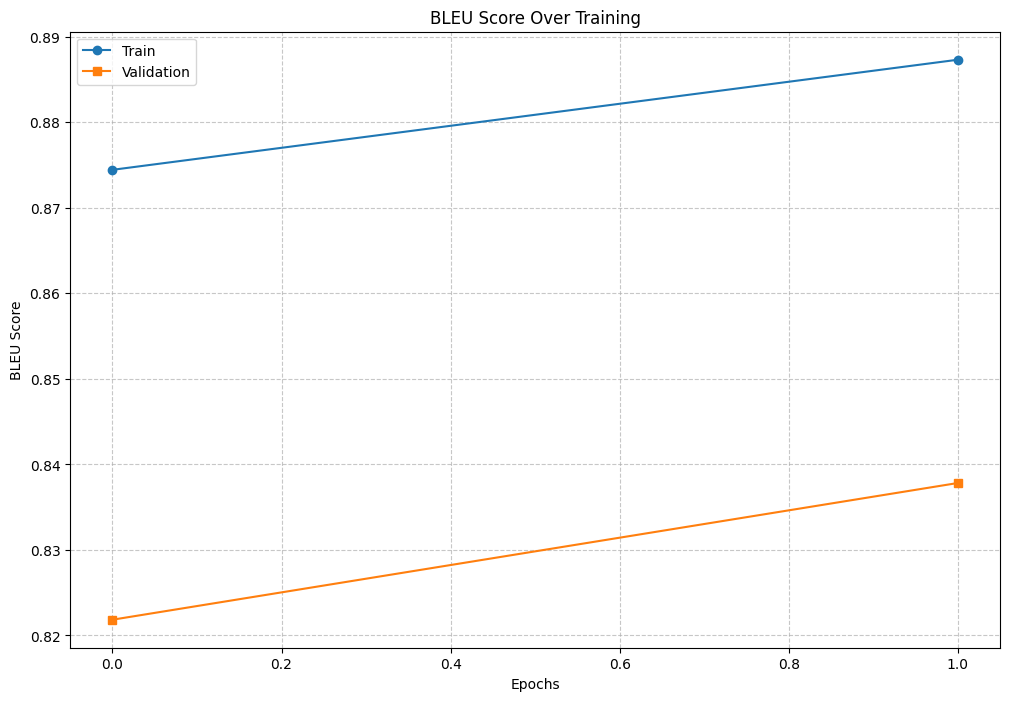

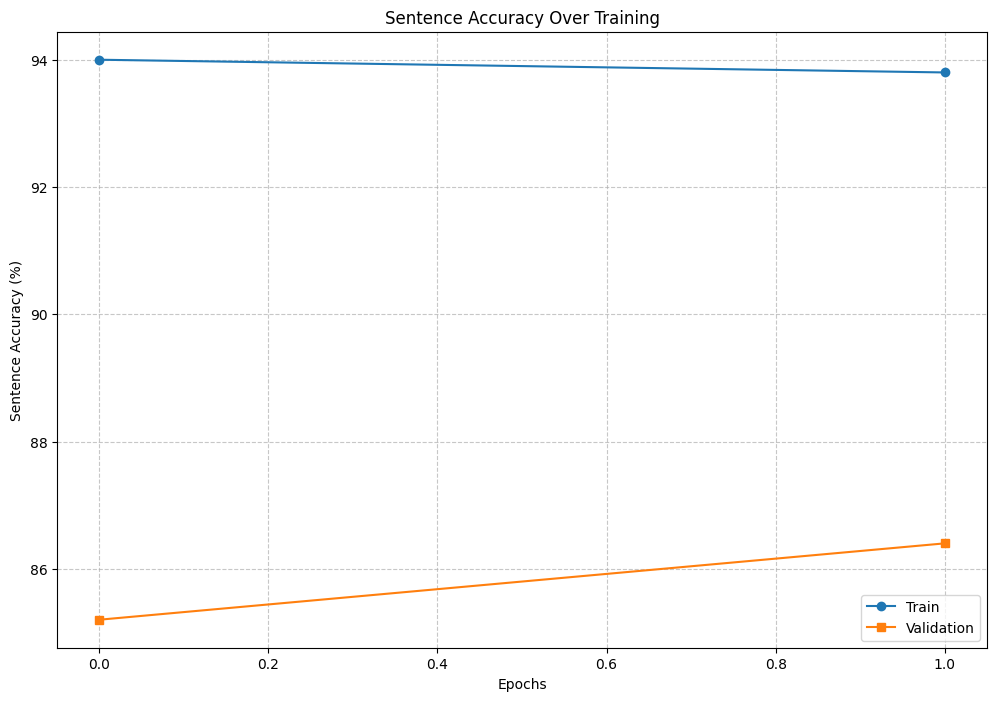

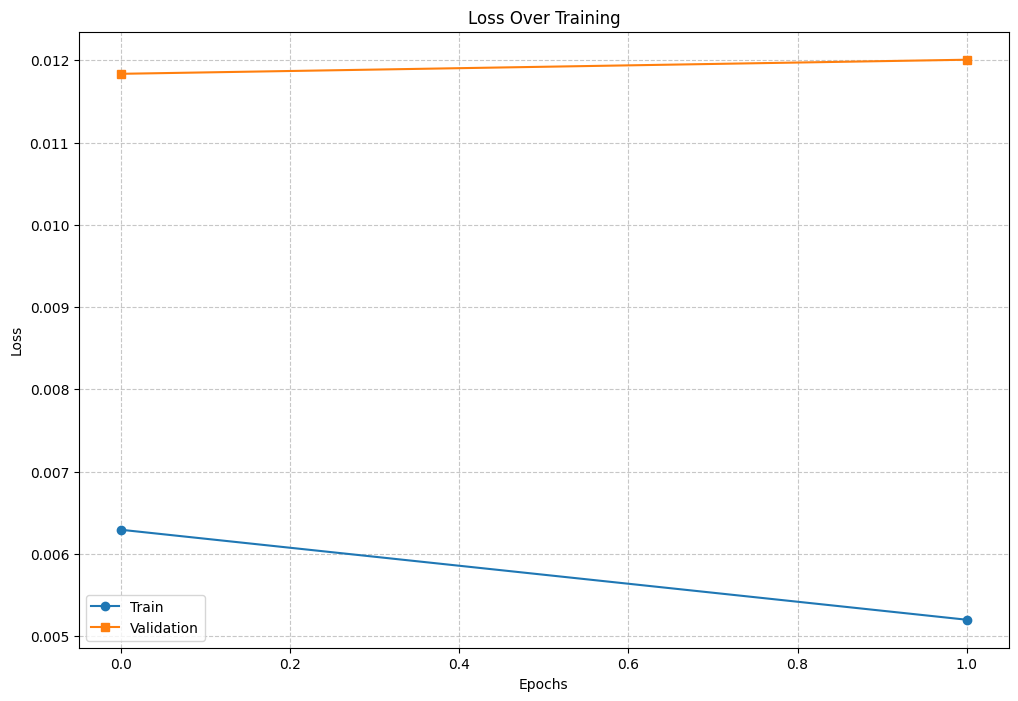

In [ ]:
extra_training_metrics = train_and_evaluate_model(
    model, train_dataloader, val_dataloader, test_dataloader,
    criterion, optimizer, device,
    pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX,
    in_vocab_transform, out_vocab_transform,
    num_epochs=2
)

In [ ]:
combined_metrics = {}
for key in metrics:
    combined_metrics[key] = metrics[key] + extra_training_metrics.get(key, [])

from pprint import pprint
pprint(combined_metrics)

{'train_accuracies': [0.9818817541821795,
                      0.9918061174132426,
                      0.9949850774328485,
                      0.9963696365205073,
                      0.9972982935566067,
                      0.9979706651537075,
                      0.9991554061993279,
                      0.9993803357829396],
 'train_bleu_scores': [0.6150534788824844,
                       0.763502729793719,
                       0.818728489242976,
                       0.842695104023665,
                       0.8696025280430986,
                       0.8746425939584337,
                       0.8744357158335742,
                       0.8873073519526753],
 'train_losses': [0.48876288716339505,
                  0.05151578533127653,
                  0.027063041809406947,
                  0.018582031720314765,
                  0.014164511310344293,
                  0.01131270904413829,
                  0.0062932803292416965,
                  0.005200036772783933],
 '

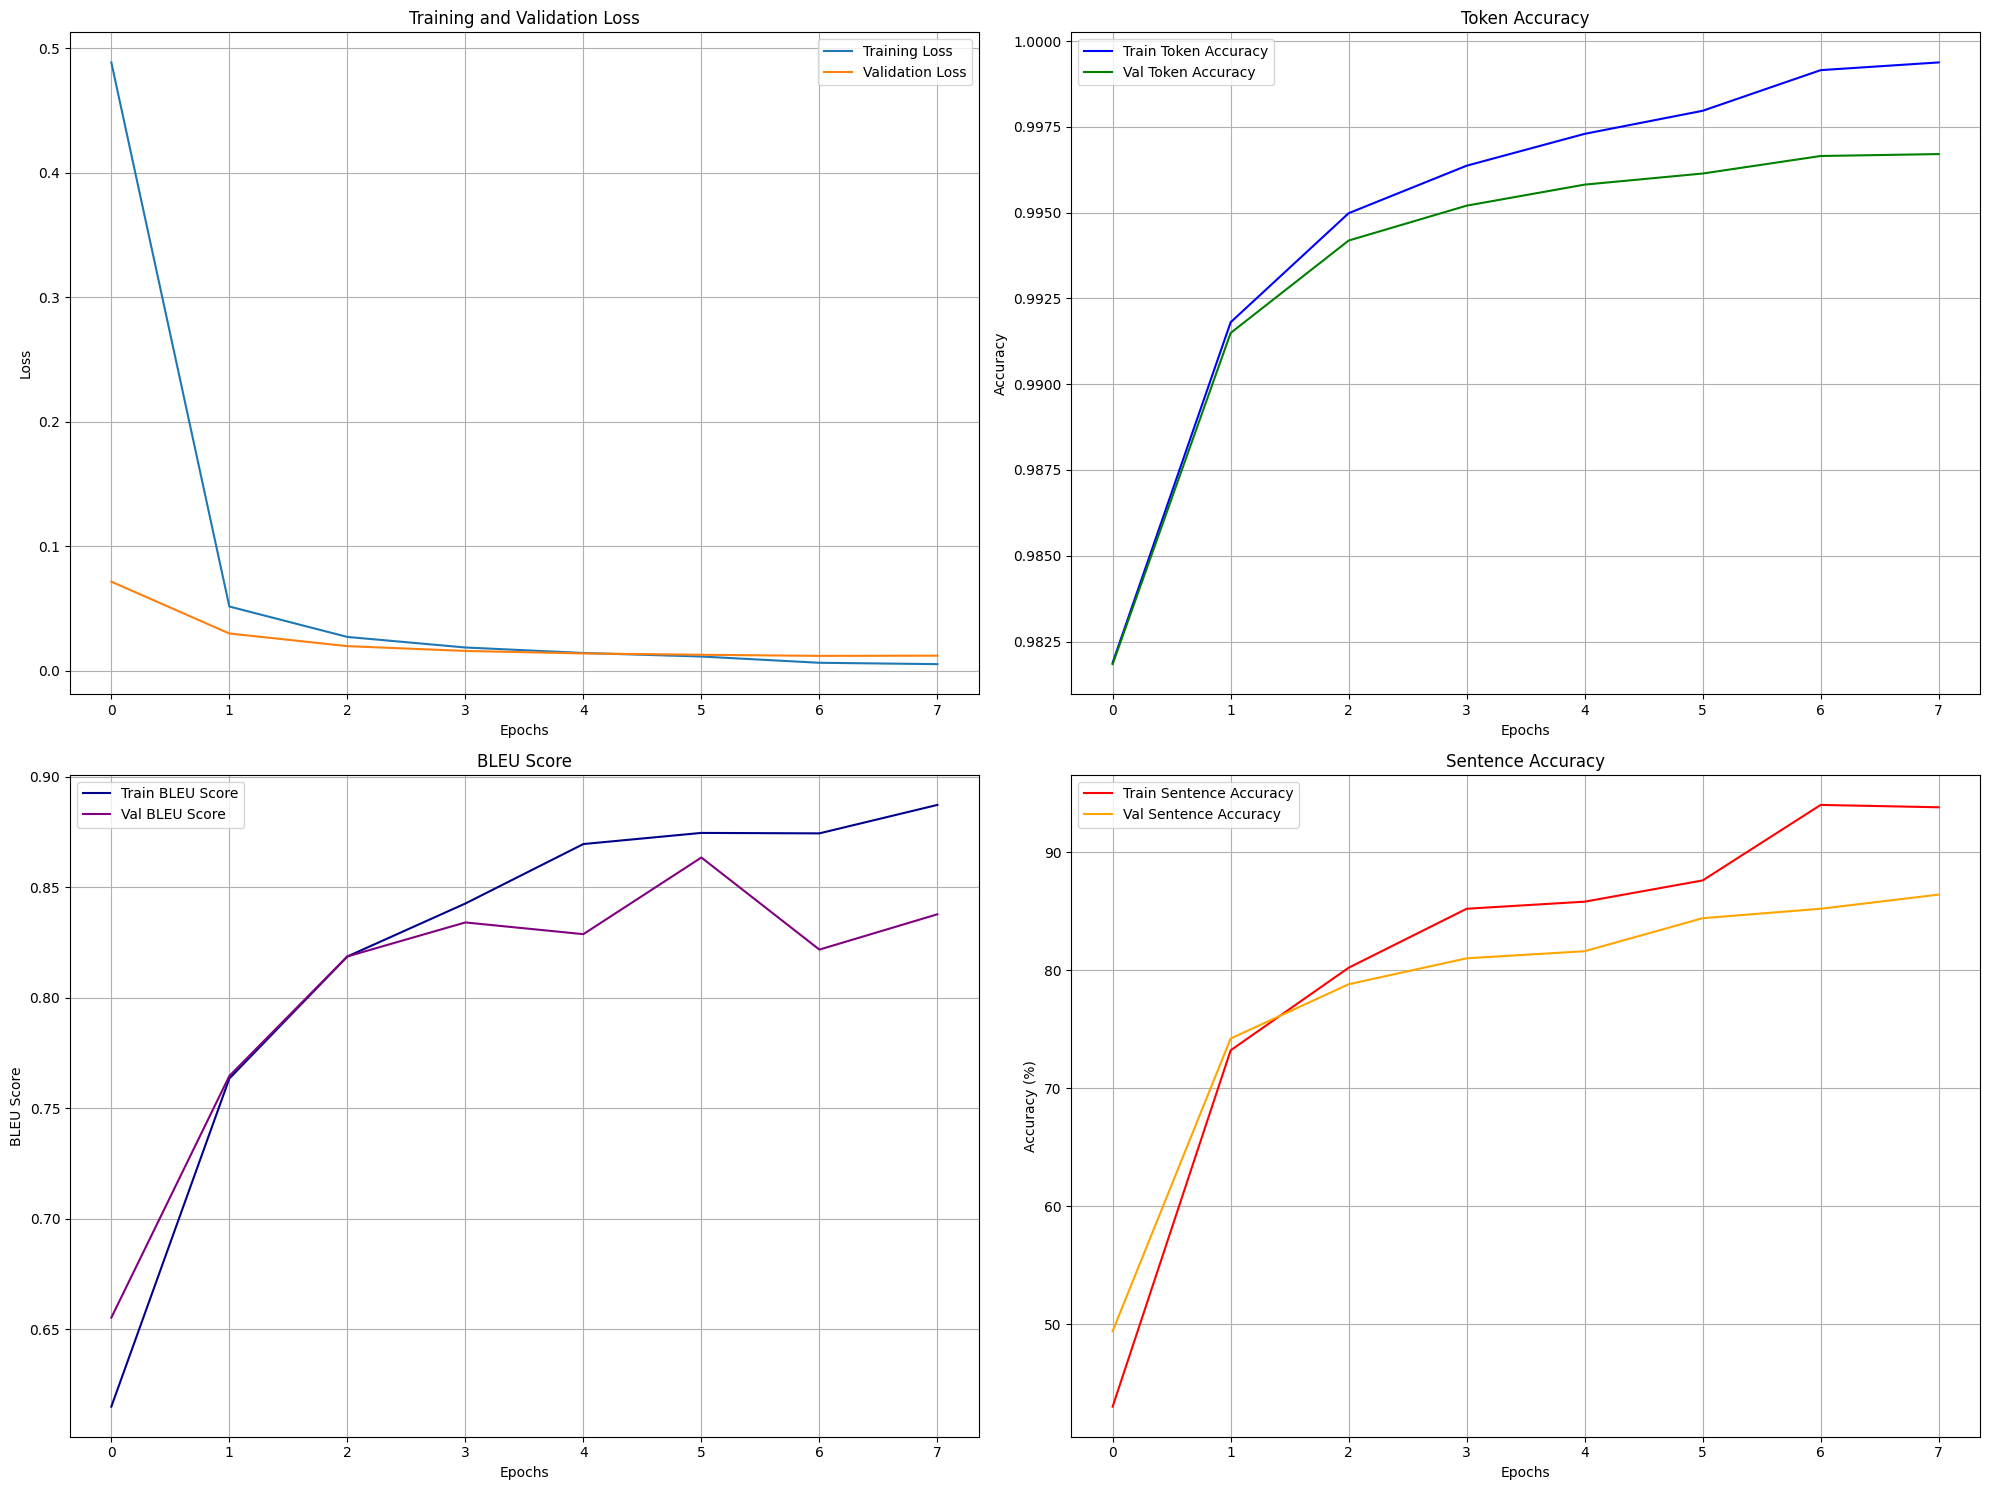

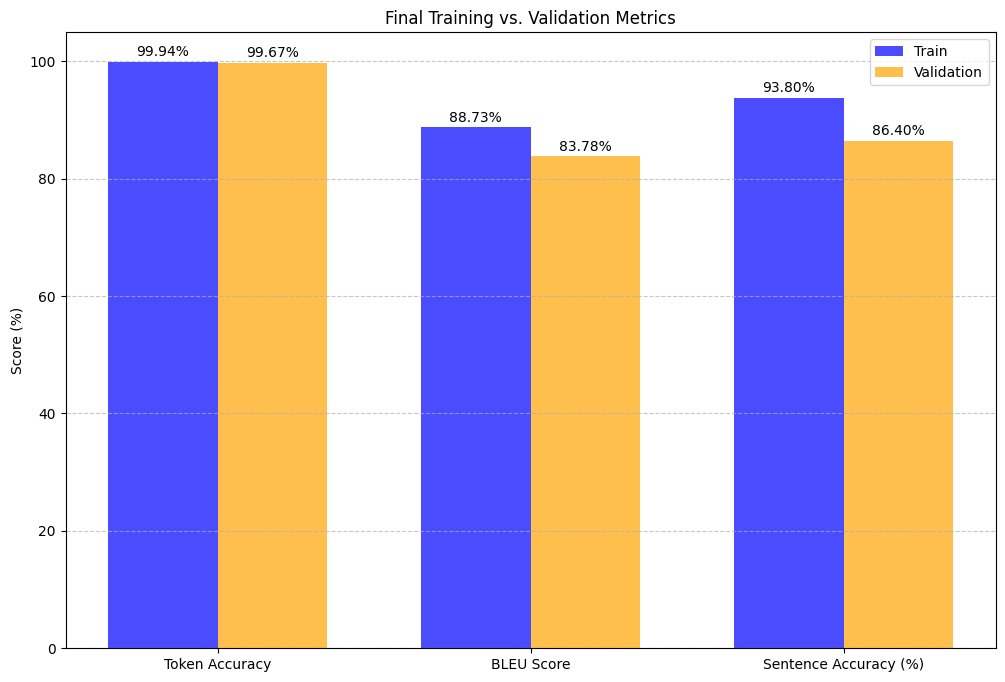

In [ ]:
visualize_metrics(combined_metrics, save_path="training_metrics.png")

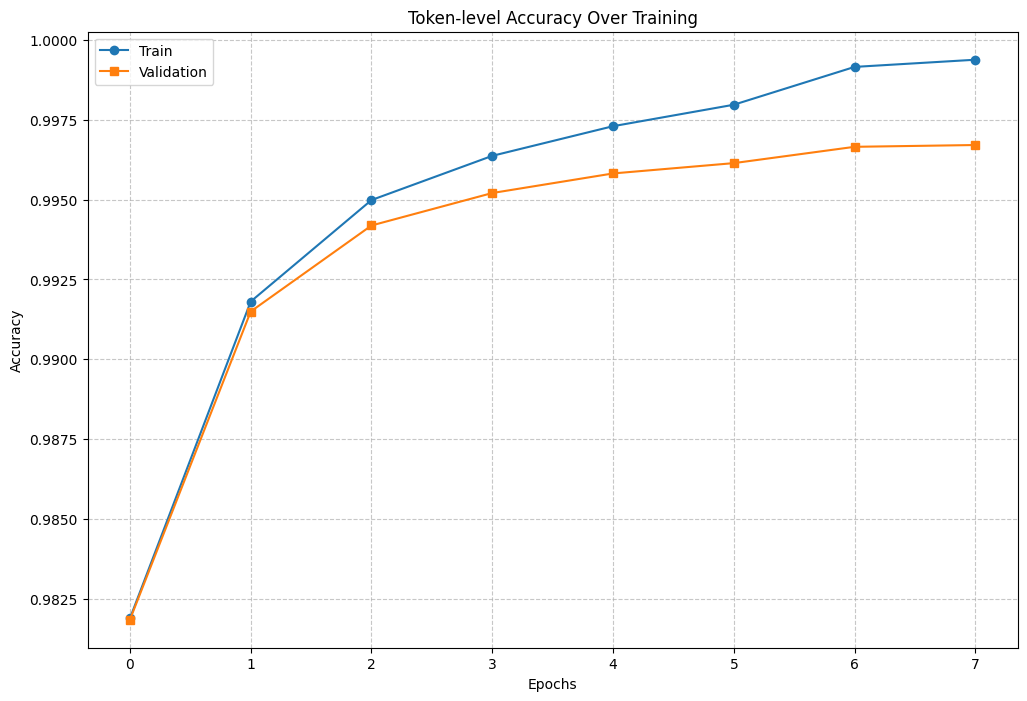

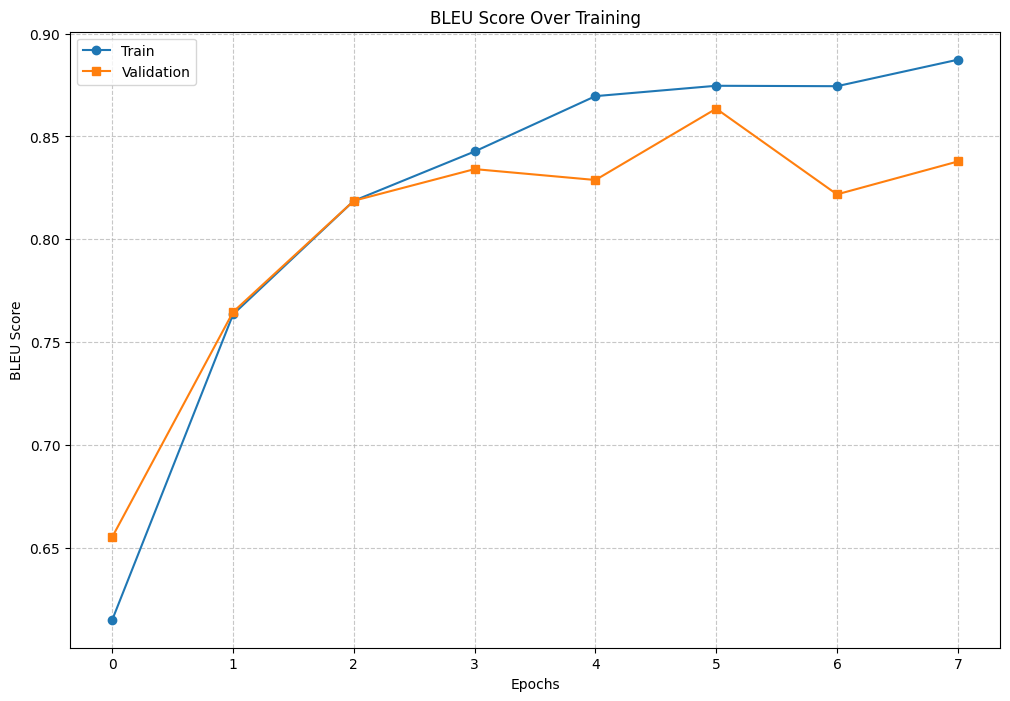

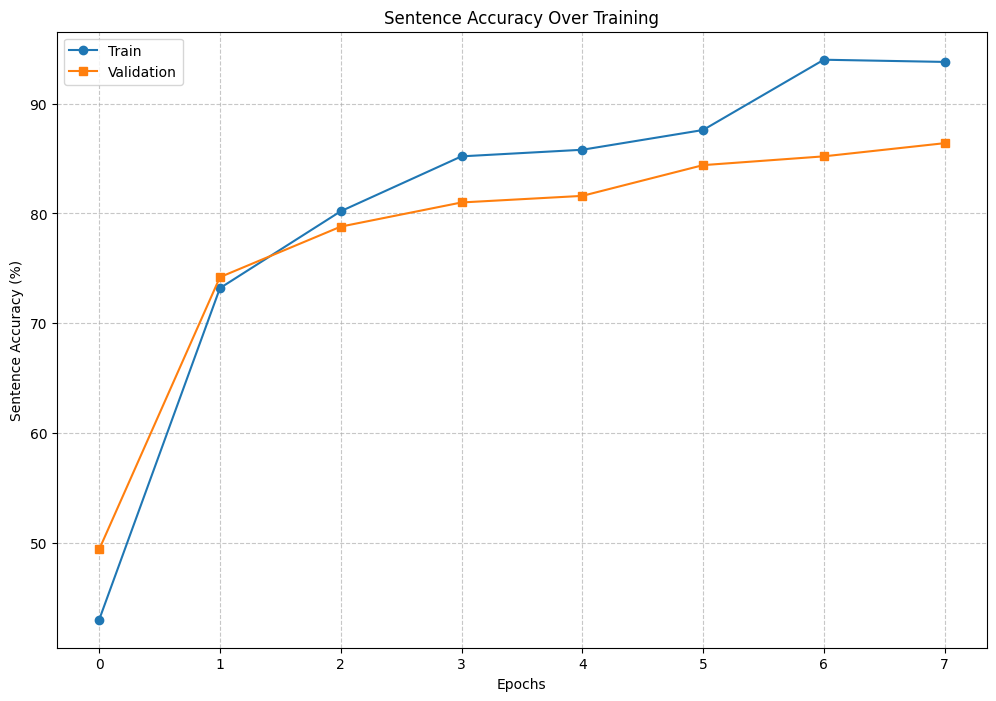

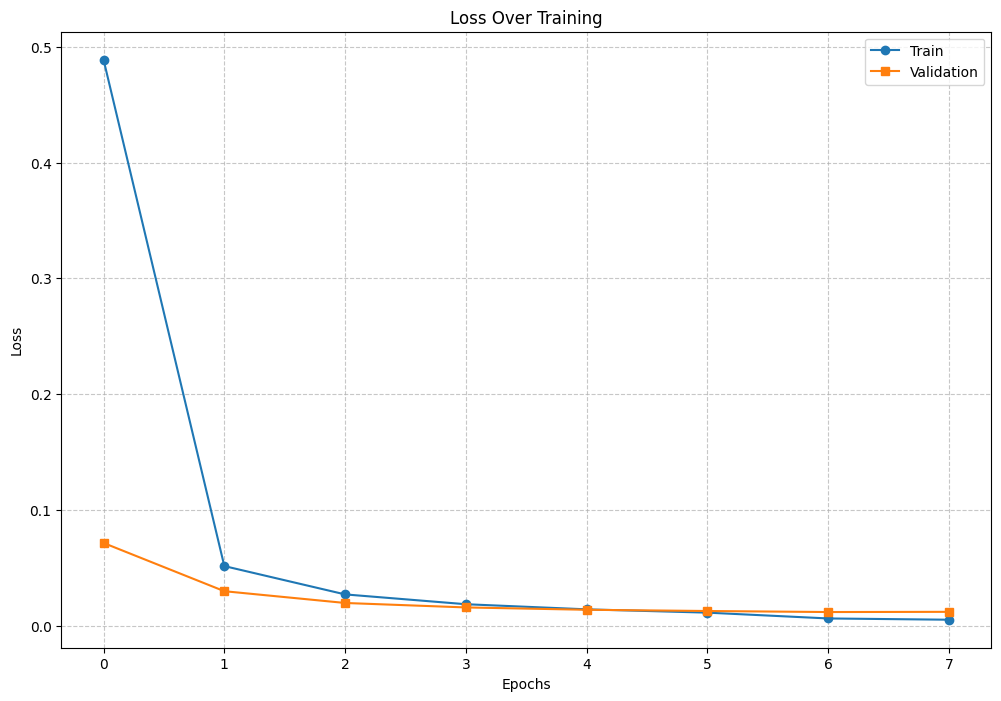

In [ ]:
plot_metric_trends(combined_metrics)

In [ ]:
torch.save(model.state_dict(), "trained_model.pth")

In [ ]:
test_results = evaluate_model_on_test(model, test_dataloader, criterion, device,
                                        pad_in_token_id, pad_out_token_id, BOS_IDX, EOS_IDX,
                                        in_vocab_transform, out_vocab_transform)

plt.figure(figsize=(10, 6))
metrics_names = ['Token Accuracy', 'BLEU Score', 'Sentence Accuracy (%)']
test_values = [test_results['test_accuracy'] * 100, test_results['test_bleu'] * 100, test_results['test_sentence_accuracy']]

train_values = [combined_metrics['train_accuracies'][-1] * 100,
                combined_metrics['train_bleu_scores'][-1] * 100,
                combined_metrics['train_sentence_accs'][-1]]

val_values = [combined_metrics['valid_accuracies'][-1] * 100,
                combined_metrics['valid_bleu_scores'][-1] * 100,
                combined_metrics['valid_sentence_accs'][-1]]




===== Evaluating Model on Test Set =====
Batch [163/163], Loss: 0.0387Test Loss: 0.0193, Test Accuracy: 0.9946


Calculating BLEU Scores: 100%|██████████| 163/163 [11:21<00:00,  4.18s/it]


Test BLEU Score: 0.8729


Evaluating Sentence Accuracy: 100%|██████████| 163/163 [11:21<00:00,  4.18s/it]


Test Sentence Accuracy: 78.03% (4053/5194)


Displaying Examples:   0%|          | 0/163 [00:00<?, ?it/s]



===== Translation Examples =====

Example 1:
Source: de mua vui cho ca hoi
Reference: để mua vui cho cả hội
Generated: để mua vui cho cá hồi
Exact match: ✗

Example 2:
Source: tro choi bat dau
Reference: trò chơi bắt đầu
Generated: trò chơi bắt đầu
Exact match: ✓

Example 3:
Source: ho dang xanh xet van de
Reference: họ đang xanh xét vấn đề
Generated: họ đang xanh xét vấn đề
Exact match: ✓

Example 4:
Source: sau chot
Reference: sau chót
Generated: sau chót
Exact match: ✓

Example 5:
Source: toi da nhan duoc mot loi moi
Reference: tôi đã nhận được một lời mời
Generated: tôi đã nhận được một lời mời
Exact match: ✓


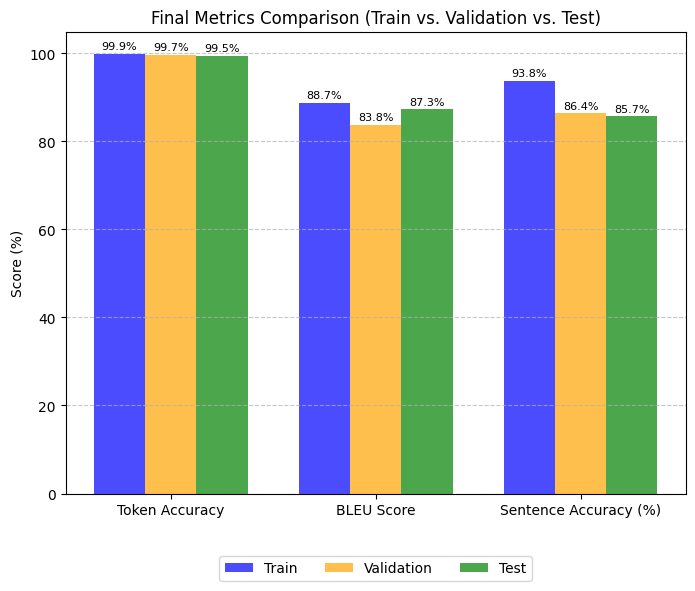

In [ ]:
x = np.arange(len(metrics_names))
width = 0.25

plt.figure(figsize=(8, 6))
plt.bar(x - width, train_values, width, label='Train', color='blue', alpha=0.7)
plt.bar(x, val_values, width, label='Validation', color='orange', alpha=0.7)
plt.bar(x + width, test_values, width, label='Test', color='green', alpha=0.7)

plt.ylabel('Score (%)')
plt.title('Final Metrics Comparison (Train vs. Validation vs. Test)')
plt.xticks(x, metrics_names)
plt.legend()

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

for i, v in enumerate(train_values):
    plt.text(i - width, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

for i, v in enumerate(val_values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

for i, v in enumerate(test_values):
    plt.text(i + width, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("final_metrics_comparison.png")
plt.show()

In [ ]:
def translate(model: torch.nn.Module, src_sentence: str, DEVICE):
    model.eval()
    src_tensor = simple_text_transform(src_sentence).to(DEVICE)
    seq_len = src_tensor.size(1)
    src_mask = torch.zeros(seq_len, seq_len, device=DEVICE).type(torch.bool)

    ys = greedy_decode(model, src_tensor, src_mask, max_len=seq_len + 5, start_symbol=BOS_IDX, DEVICE=DEVICE)
    tgt_tokens = ys.squeeze(0).cpu().numpy().tolist()

    tokens = out_vocab_transform.lookup_tokens(tgt_tokens)
    num_words = len(src_sentence.split())
    translation = " ".join(tokens).replace("<seqstart>", "").replace("<seqend>", "").strip()
    if len(translation.split()) > num_words:
        translation = " ".join(translation.split()[:num_words])
    return translation

In [ ]:
test_sentence = "van phong cua anh ay thuan tien den ga"
translation = translate(model, test_sentence, device)
print("Input sentence:", test_sentence)
print("Translated sentence:", translation)

Input sentence: van phong cua anh ay thuan tien den ga
Translated sentence: văn phòng của anh ấy thuận tiện đến ga


In [ ]:
test_sentence = "chung toi muon tham du buoi hoa nhac toi nay."
translation = translate(model, test_sentence, device)
print("Input sentence:", test_sentence)
print("Translated sentence:", translation)

Input sentence: chung toi muon tham du buoi hoa nhac toi nay.
Translated sentence: chúng tôi muốn tham dự buổi hòa nhạc tối nay


In [ ]:
test_sentence = "ti nua ve nha dan ba noi di hoc boi"
translation = translate(model, test_sentence, device)
print("Input sentence:", test_sentence)
print("Translated sentence:", translation)

Input sentence: ti nua ve nha dan ba noi di hoc boi
Translated sentence: tí nữa về nhà đàn bà nội đi học bơi


In [ ]:
test_sentence = "cuoc chien nay khong chi co danh nhau va cat giam luong thuc"
translation = translate(model, test_sentence, device)
print("Input sentence:", test_sentence)
print("Translated sentence:", translation)

Input sentence: cuoc chien nay khong chi co danh nhau va cat giam luong thuc
Translated sentence: cuộc chiến này không chỉ có đánh nhau và cắt giảm lương thực


In [ ]:
test_sentence = "day la bai thi cuoi ky mon khoa hoc du lieu"
translation = translate(model, test_sentence, device)
print("Input sentence:", test_sentence)
print("Translated sentence:", translation)

Input sentence: day la bai thi cuoi ky mon khoa hoc du lieu
Translated sentence: đây là bài thi cuối kỳ môn khoa học dữ liệu
